In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [6]:
# Load your dataset
df = pd.read_csv("/content/all_stocks_5yr.csv")

# Check the column names
print(df.columns)



Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')


In [7]:
print(df.head())

         date   open   high    low  close      volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500.0  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000.0  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000.0  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500.0  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900.0  AAL


In [9]:
unique_companies = df['Name'].unique()

In [10]:
print("✅ Unique Company Names:")
for name in unique_companies:
    print(name)

✅ Unique Company Names:
AAL
AAPL
AAP
ABBV
ABC
ABT
ACN
ADBE
ADI
ADM
ADP
ADSK
ADS
AEE
AEP
AES
AET
AFL
AGN
AIG
AIV
AIZ
AJG
AKAM
ALB
ALGN
ALK
ALLE
ALL
ALXN
AMAT
AMD
AME
AMGN
AMG
AMP
AMT
AMZN
ANDV
ANSS
ANTM
AON
AOS
APA
APC
APD
APH
APTV
ARE
ARNC
ATVI
AVB
AVGO
AVY
AWK
AXP
AYI
AZO
A
BAC
BAX
BA
BBT
BBY
BDX
BEN
BF.B
BHF
BHGE
BIIB
BK
BLK
BLL
BMY
BRK.B
BSX
BWA
BXP
CAG
CAH
CAT
CA
CBG
CBOE
CBS
CB
CCI
CCL
CDNS
CELG
CERN
CFG
CF
CHD
CHK
CHRW
CHTR
CINF
CI
CLX
CL
CMA
CMCSA
CME
CMG
CMI
CMS
CNC
CNP
COF
COG
COL
COO
COP
COST
COTY
CPB
CRM
CSCO
CSRA
CSX
CTAS
CTL
CTSH
CTXS
CVS
CVX
CXO
C
DAL
DE
DFS
DGX
DG
DHI
DHR
DISCA
DISCK
DISH
DIS
DLR
DLTR
DOV
DPS
DRE
DRI
DTE
DUK
DVA
DVN
DWDP
DXC
D
EA
EBAY
ECL
ED
EFX
EIX
EL
EMN
EMR
EOG
EQIX
EQR
EQT
ESRX
ESS
ES
ETFC
ETN
ETR
EVHC
EW
EXC
EXPD
EXPE
EXR
FAST
FBHS
FB
FCX
FDX
FE
FFIV
FISV
FIS
FITB
FLIR
FLR
FLS
FL
FMC
FOXA
FOX
FRT
FTI
FTV
F
GD
GE
GGP
GILD
GIS
GLW
GM
GOOGL
GOOG
GPC
GPN
GPS
GRMN
GS
GT
GWW
HAL
HAS
HBAN
HBI
HCA
HCN
HCP
HD
HES
HIG
HII
HLT
HOG
HOLX
HON
HPE
HPQ
HP
HRB
HRL
H

In [11]:
print(f"\nTotal Unique Companies: {len(unique_companies)}")



Total Unique Companies: 290


In [12]:
company_name = input("Enter the company name exactly (e.g., TATA STEEL): ")


Enter the company name exactly (e.g., TATA STEEL): AMZN


In [14]:
company_df = df[df['Name'] == company_name].copy()
if company_df.empty:
    raise ValueError(f"Company '{company_name}' not found in dataset.")


In [15]:
# Use only 'Close' prices
close_prices = company_df[['close']].values

# Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

In [18]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - 60:]

def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)

sequence_length = 60
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

In [19]:
# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [20]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0235
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 9.9711e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 9.1388e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 7.2415e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 7.3561e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 6.7439e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 7.3436e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 7.9985e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 7.0398e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 6.4286e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 5.5235e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 6.7522e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 6.4455e-04
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━

In [21]:
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step


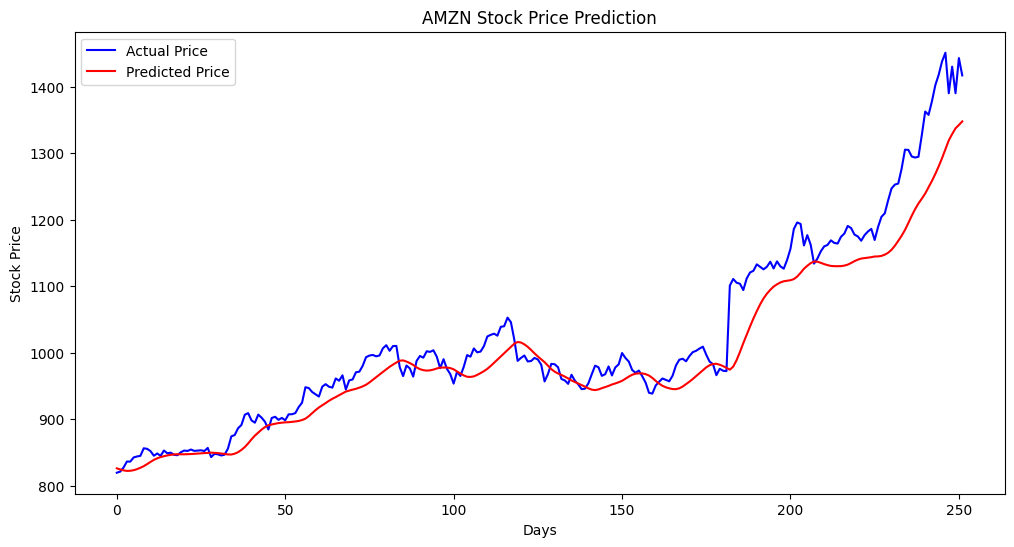

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(real_prices, color='blue', label='Actual Price')
plt.plot(predicted_prices, color='red', label='Predicted Price')
plt.title(f'{company_name} Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [23]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

next_day_pred = model.predict(last_60_days)
predicted_next_day_price = scaler.inverse_transform(next_day_pred)

print(f"\n📈 Predicted Next Day Price for {company_name}: ₹{predicted_next_day_price[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

📈 Predicted Next Day Price for AMZN: ₹1351.36


In [25]:
# Get actual previous day price (original scale)
actual_prev_day_price = scaler.inverse_transform(scaled_data[-1].reshape(-1, 1))[0][0]

print(f"🔵 Actual Closing Price of Previous Day for {company_name}: ₹{actual_prev_day_price:.2f}")


🔵 Actual Closing Price of Previous Day for AMZN: ₹1416.78


In [26]:
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((real_prices - predicted_prices) / real_prices)) * 100
accuracy = 100 - mape
print(f"🧪 Model Accuracy (approx): {accuracy:.2f}%")


🧪 Model Accuracy (approx): 97.08%


In [29]:
model.save(f"Amazon_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


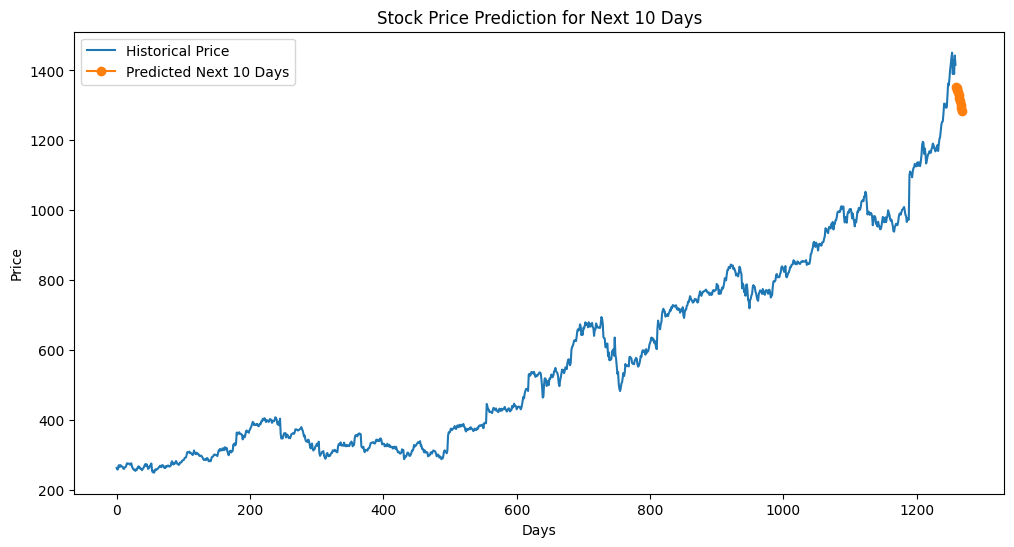

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Assume 'scaled_data' is your normalized close prices array for the company
# and 'model' is your trained LSTM model
# 'scaler' is your MinMaxScaler used to scale the data

sequence_length = 60
num_days_to_predict = 10

# Start with last 60 days data
input_seq = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)

predicted_scaled = []

for _ in range(num_days_to_predict):
    # Predict next day
    pred = model.predict(input_seq)[0][0]
    predicted_scaled.append(pred)

    # Append prediction to input sequence and remove oldest day
    input_seq = np.append(input_seq[:,1:,:], [[[pred]]], axis=1)

# Inverse scale the predicted values
predicted_prices = scaler.inverse_transform(np.array(predicted_scaled).reshape(-1, 1))

# Plotting
plt.figure(figsize=(12,6))

# Plot historical actual prices
plt.plot(scaler.inverse_transform(scaled_data), label='Historical Price')

# Extend x-axis for predicted days
future_days = range(len(scaled_data), len(scaled_data) + num_days_to_predict)
plt.plot(future_days, predicted_prices, marker='o', label='Predicted Next 10 Days')

plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Stock Price Prediction for Next 10 Days')
plt.legend()
plt.show()


In [36]:
from datetime import timedelta
import pandas as pd

# Convert last_date to datetime if it's not already
last_date = pd.to_datetime(company_df['date'].iloc[-1])

# Now create future dates
future_dates = [last_date + timedelta(days=i) for i in range(1, num_days_to_predict + 1)]


In [38]:
print(type(last_date))  # Should show <class 'pandas._libs.tslibs.timestamps.Timestamp'> or datetime.datetime


<class 'str'>


In [40]:
from datetime import timedelta
import pandas as pd

# Make sure the entire 'Date' column is datetime
company_df['date'] = pd.to_datetime(company_df['date'])

# Now get last_date from the properly converted column
last_date = company_df['date'].iloc[-1]

# Confirm type
print(type(last_date))  # should print <class 'pandas._libs.tslibs.timestamps.Timestamp'>

# Create future dates
future_dates = [last_date + timedelta(days=i) for i in range(1, num_days_to_predict + 1)]


<class 'pandas._libs.tslibs.timestamps.Timestamp'>


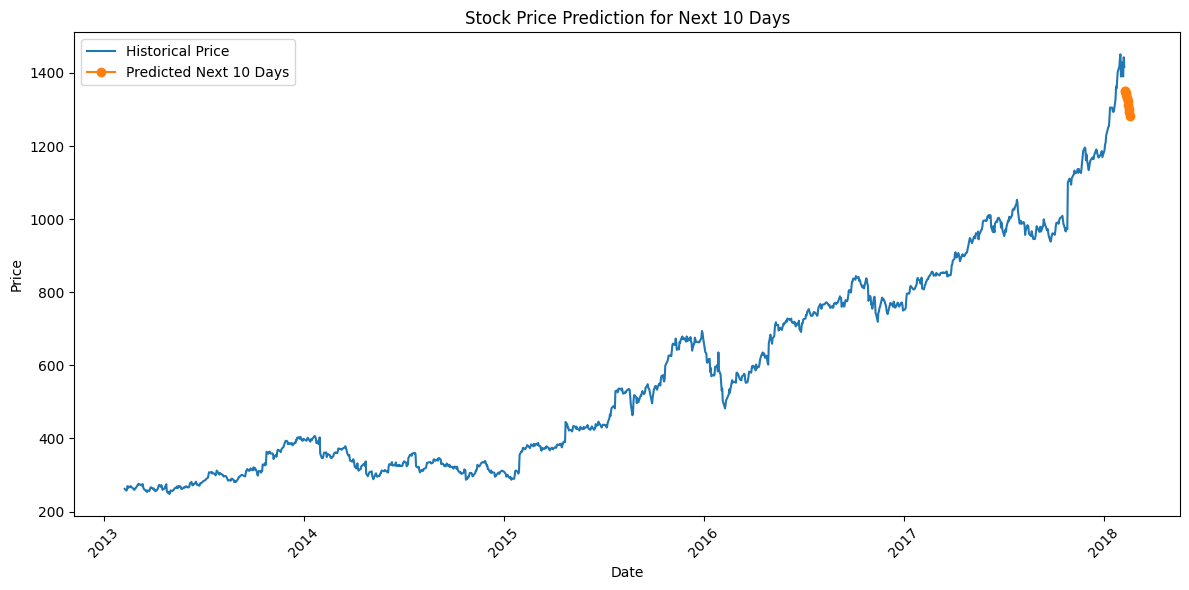

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# Assume:
# company_df['Date'] contains historical dates sorted ascending
# scaled_data is your normalized close prices
# predicted_prices is predicted next 10 days prices (inverse scaled)

num_days_to_predict = 10

# Get last historical date
last_date = company_df['date'].iloc[-1]

# Create date range for predicted days
future_dates = [last_date + timedelta(days=i) for i in range(1, num_days_to_predict + 1)]

# Plot
plt.figure(figsize=(12,6))

# Historical prices plot with dates
plt.plot(company_df['date'], scaler.inverse_transform(scaled_data), label='Historical Price')

# Predicted prices plot with future dates
plt.plot(future_dates, predicted_prices, marker='o', label='Predicted Next 10 Days')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'Stock Price Prediction for Next {num_days_to_predict} Days')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
